In [1]:
# Load Library
import os
import sys
import timm
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

In [2]:
# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device:  NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
# Load Vision Transformer Model Locally
local_model = './rice_model_vit_5_class_new_model.pth'
model = timm.create_model('vit_tiny_patch16_224', pretrained=False, num_classes=5)
if os.path.exists(local_model):
    model.load_state_dict(torch.load(local_model, map_location=device))
else:
    print(f"Model file {local_model} does not exist. Please check the path.")
model.to(device)
# Set Model to Evaluation Mode
model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()


In [4]:
# Test with test dataset
dataset_dir = './new_dataset/test'

In [5]:
# Sample Transform
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]), 
])

In [6]:
# Load the Dataset
test_dataset = ImageFolder(root=dataset_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [7]:
# Check availbility of dataset
print(f"Number of test images: {len(test_dataset)}")

Number of test images: 7500


In [8]:
# Test the Model Predictions
predictions = model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = predictions(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
# predictions results
print(f'Number of correct predictions: {correct}')
print(f'Number of total predictions: {total}')

Accuracy of the model on the test images: 93.85%
Number of correct predictions: 7039
Number of total predictions: 7500


In [9]:
# Classfication Report
from sklearn.metrics import classification_report, confusion_matrix, f1_score
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
report = classification_report(y_true, y_pred, target_names=test_dataset.classes)
f1 = f1_score(y_true, y_pred, average="weighted")
print("Classification Report:\n", report)
print("F1 Score: ", f1)

Classification Report:
               precision    recall  f1-score   support

     Arborio       1.00      0.80      0.89      1500
     Basmati       0.98      0.95      0.97      1500
      Ipsala       1.00      0.99      0.99      1500
     Jasmine       0.94      0.96      0.95      1500
   Karacadag       0.82      1.00      0.90      1500

    accuracy                           0.94      7500
   macro avg       0.95      0.94      0.94      7500
weighted avg       0.95      0.94      0.94      7500

F1 Score:  0.9386000862631302


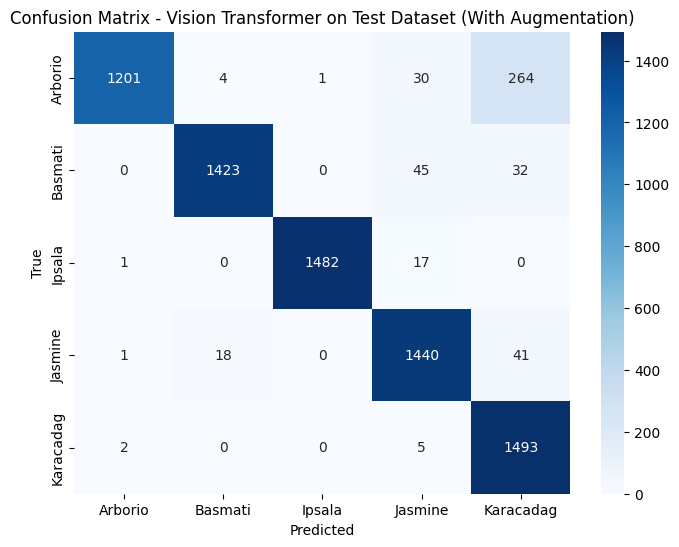

In [13]:
# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Vision Transformer on Test Dataset (With Augmentation)')
plt.savefig('confusion_matrix_test_5_class_new_model.png')
plt.show()

In [11]:
from sklearn.metrics import precision_score, recall_score
# Precision and Recall
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')

print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")

Precision (Weighted): 0.9467
Recall (Weighted): 0.9385


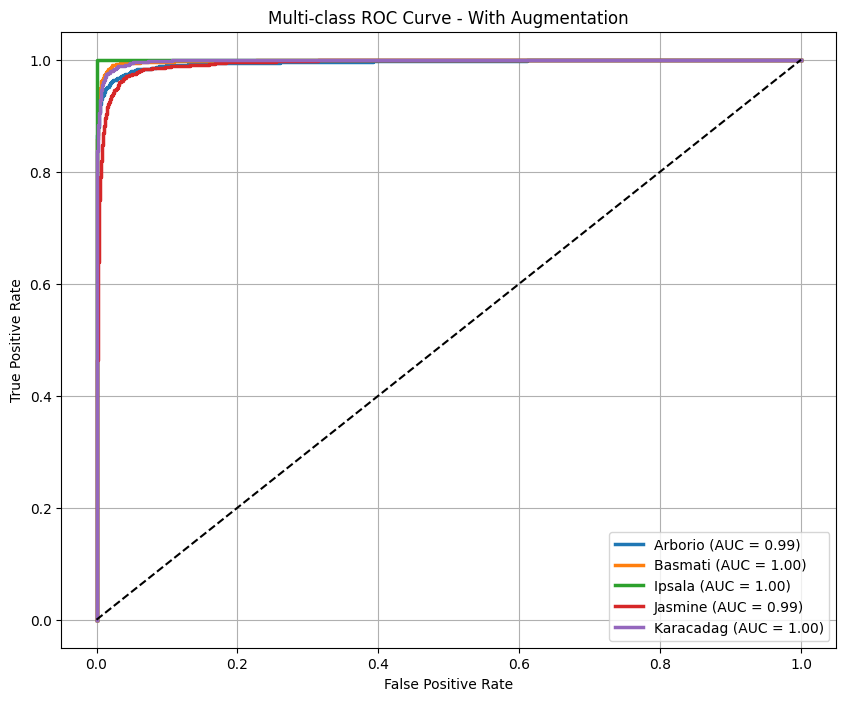

In [12]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
# Number of classes
num_classes = len(test_dataset.classes)

# Store all predictions and labels
y_true = []
y_score = []

# Put model in eval mode
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)  # raw logits
        y_score.extend(outputs.cpu().numpy())  # Save logits or probabilities
        y_true.extend(labels.cpu().numpy())

# Convert to NumPy arrays
y_true = np.array(y_true)
y_score = np.array(y_score)

# Binarize the labels for one-vs-rest strategy
y_true_bin = label_binarize(y_true, classes=range(num_classes))

# Plot ROC curve for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], lw=2.5, label=f"{test_dataset.classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve - With Augmentation')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('ROC_Augmentation_5_class_new_model.png')
plt.show()


In [11]:
# Open File Dialog for Identification testing
from PIL import Image
from tkinter import Tk
from tkinter.filedialog import askopenfilename
def open_file_dialog():
    Tk().withdraw()  # Hide the root window
    file_path = askopenfilename(title="Select an image file", filetypes=[("Image files", "*.jpg;*.jpeg;*.png")])
    return file_path
# Convert Image to Tensor
from torchvision import transforms
def image_to_tensor(image_path):
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    return image_tensor
# Load and Preprocess Image
def load_and_preprocess_image(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"The file {image_path} does not exist.")
    image_tensor = image_to_tensor(image_path)
    return image_tensor
# Predict Function
def predict_image(image_tensor):
    with torch.no_grad():
        output = model(image_tensor)
        _, predicted = torch.max(output, 1)
        return predicted.item()

# Main Execution
image_path = open_file_dialog()
if not image_path:
    print("No file selected. Exiting.")
image_tensor = load_and_preprocess_image(image_path)
prediction = predict_image(image_tensor)
# Print Prediction Result
print(f"Image: {image_path}")
print(f"Prediction Class: {prediction}")
class_names = ['Broken', 'Full', 'Mixed']
print(f"Predicted class: {class_names[prediction]}")
print("Accuracy: ")  # Placeholder for accuracy, as we are not evaluating on a dataset here
Tk().destroy()

AssertionError: Input width (392) doesn't match model (224).